# Sparse Sheaf Signal Processing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from vdm import VDM
import cvxpy as cp
from sklearn.linear_model import OrthogonalMatchingPursuit
from wavelet import Wavelet
from builder import CochainSample # builder.py file provided by project supervisor
import pandas as pd
from tqdm import tqdm
import seaborn as sns
from collections import defaultdict
from utils import fibonacci_sphere, geodetic_to_ecef, project_to_tangent
from tsp import TSP
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# Synthetic Datasets

## Random Point Cloud in a Cube

In [2]:
# Generate a cube in R^3 with uniformly random points
N = 300 # number of points in the cloud
cube_point_cloud = np.random.uniform(-0.5,0.5,N*3).reshape((N, 3)) # points
# Create a topological signal processing object
cube = TSP(cube_point_cloud, eps=0.1, eps_pca=0.05, k=30, gamma=0.95, laplacian_code = 'Connection')

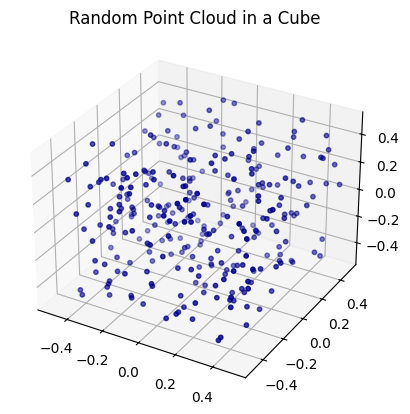

In [3]:
cube.plot_points('Random Point Cloud in a Cube')

In [3]:
# Print manifold dimension
print(f"Estimated dimension of the manifold: {cube.estimate_dim()}")

Estimated dimension of the manifold: 2


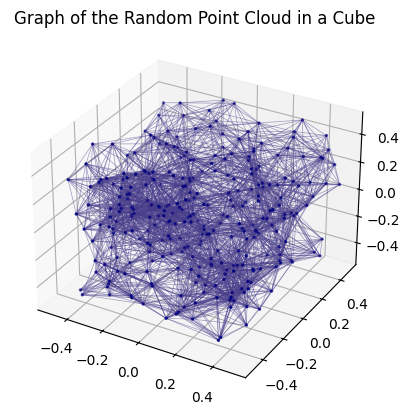

In [5]:
cube.plot_graph("Graph of the Random Point Cloud in a Cube")

### Signal Compression: Experiment 1

The experiment uses a predefined point cloud, and for each laplacian separately defines a set of signals to be compressed, using wavelet dictionaries of various sizes for the compression. Signals are defined once for each laplacian, from random linear combinations of the largest dictionary's atoms. All dictionaries are overcomplete.

```
- For each laplacian:
    - Create a topological signal processing (TSP) object
    - For each number of scales *in descending order*:
        1. Create a wavelet dictionary using the current laplacian and number of scales (use all shifts)
        1.1 If the number of scales is the highest:
            - Generate signals from random linear combinations of this dictionary's atoms
        2. Sparsify the signals
        3. Compute sparsity and NMSE
```

**Hyperparameters**:
* eps=0.1
* eps_pca=0.05
* k=30
* gamma=0.97

**Initialization**:
* Numbers of Scales: $[2, 3, 5, 7]$
* Scales: `[2**(j-num_scal//2) for j in range(num_scal)]`
* Shifts: $[1, ..., N]$
* Laplacians:
    * Connection = $S - D$
    * Connection Normalized = $D^{-1} S - I$
    * Trivial = $D - W$
    * Trivial Normalized = $D^{-\frac{1}{2}} (D - W) D^{\frac{1}{2}}$
    * Sheaf = $\delta^T \delta$

**Signals**:
* Defined for each laplacian separately as random linear combinations of the laplacian's largest dictionary's atoms

In [3]:
from collections import defaultdict

# Initialize result dictionaries
sparsity_results = defaultdict(dict)
nmse_results = defaultdict(dict)
num_scales = [2, 3, 5, 7] # number of scales to use
laplacians = ['Connection', 'Connection Normalized', 'Trivial', 'Trivial Normalized', 'Sheaf']

# Hyperparameters
eps=0.1
eps_pca=0.05
k=30
gamma=0.97

for laplacian in laplacians:

    # Create TSP (topological signal processing) object
    cube = TSP(cube_point_cloud, eps=eps, eps_pca=eps_pca, k=k, laplacian_code=laplacian, gamma=gamma)

    # Generate signals for the corresponding laplacian
    # signals, cov, signals_GT = cube.generate_kraichnan_signals(num_signals=2)

    signals = None

    for num_scal in num_scales[::-1]:
        # Create dictionary
        dictionary = cube.create_dictionary(scales=[2**(j-num_scal//2) for j in range(num_scal)])

        if num_scal == num_scales[-1]:
            # Generate signals for the corresponding laplacian and dictionary
            signals = cube.generate_random_lc_signals(dictionary, num_signals=10)

        # Sparsify signals
        sparse_signals = cube.sparsify_signals(signals, dictionary)

        # Compute sparsity
        sparsity =  cube.compute_sparsity(sparse_signals)
        
        # Compute NMSE
        nmse = cube.compute_NMSE(signals, sparse_signals, dictionary)

        # Add sparsity and NMSE to the dictionaries
        sparsity_results[laplacian][num_scal] = sparsity
        nmse_results[laplacian][num_scal] = nmse

In [ ]:
sparsity_results

defaultdict(dict,
            {'Connection': {7: array([0.00190476, 0.00214286, 0.00190476, 0.00261905, 0.00190476,
                     0.00190476, 0.00214286, 0.00214286, 0.00238095, 0.00238095]),
              5: array([0.01166667, 0.01      , 0.01066667, 0.01166667, 0.011     ,
                     0.01166667, 0.00966667, 0.01133333, 0.01066667, 0.01      ]),
              3: array([0.06388889, 0.06388889, 0.06388889, 0.06333333, 0.06611111,
                     0.06388889, 0.06333333, 0.06388889, 0.06222222, 0.06333333]),
              2: array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])},
             'Connection Normalized': {7: array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]),
              5: array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]),
              3: array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]),
              2: array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])},
             'Trivial': {7: array([0.1, 0.1, 0.1, 0.1, 0.1, 

In [5]:
nmse_results

defaultdict(dict,
            {'Connection': {7: array([1.76118624e-15, 1.07058452e-16, 5.88280215e-16, 1.00355347e-14,
                     1.15543198e-11, 3.01724554e-17, 1.19878097e-15, 7.85908649e-16,
                     3.31989308e-15, 4.15241939e-16]),
              5: array([3.47373087e-16, 7.75360305e-18, 7.37621338e-18, 2.72572725e-16,
                     1.18477292e-16, 2.42574087e-15, 1.05781536e-17, 1.66387860e-16,
                     2.01525969e-17, 4.66755634e-17]),
              3: array([1.57346894e-17, 2.23740914e-17, 2.16311339e-17, 6.01095576e-17,
                     1.08046911e-16, 1.78207314e-17, 8.33905311e-17, 3.83984853e-17,
                     3.10144861e-17, 2.66283285e-17]),
              2: array([1.41279232e-10, 8.52520112e-11, 1.15706147e-10, 1.76132056e-10,
                     2.64607797e-10, 1.01300379e-10, 7.97424630e-11, 1.20535738e-10,
                     7.94376869e-11, 1.27372284e-10])},
             'Connection Normalized': {7: array([1.6733

In [6]:
import pickle

with open('cube_sparsity_results.pkl', 'wb') as f:
    pickle.dump(sparsity_results, f)

with open('cube_nmse_results.pkl', 'wb') as f:
    pickle.dump(nmse_results, f)

In [ ]:
sparsity_results = pickle.load(open('cube_sparsity_results.pkl', 'rb'))
nmse_results = pickle.load(open('cube_nmse_results.pkl', 'rb'))

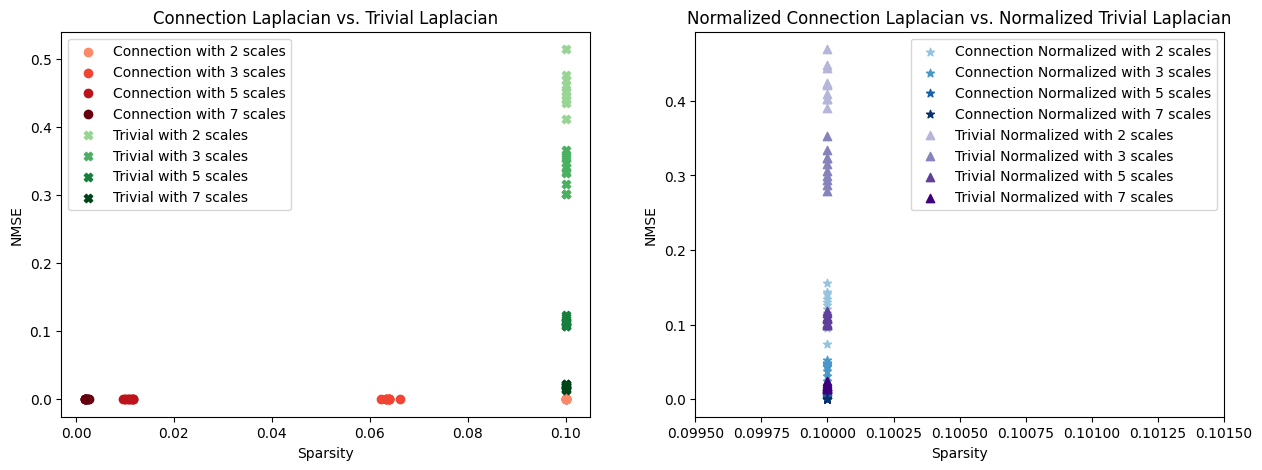

In [7]:
# Scatterplot of sparsity vs. nmse
fig, ax = plt.subplots(1,2, figsize=(15,5))
colors = {
    'Connection': plt.cm.Reds(np.linspace(0.4, 1, len(num_scales))),
    'Connection Normalized': plt.cm.Blues(np.linspace(0.4, 1, len(num_scales))),
    'Trivial': plt.cm.Greens(np.linspace(0.4, 1, len(num_scales))),
    'Trivial Normalized': plt.cm.Purples(np.linspace(0.4, 1, len(num_scales))),
    'Sheaf': plt.cm.Greys(np.linspace(0.4, 1, len(num_scales)))
}
markers = {'Connection': 'o', 'Connection Normalized': '*', 'Trivial': 'X', 'Trivial Normalized': '^', 'Sheaf': 'X',}
for laplacian in ['Connection','Trivial']:
    for l, num_scal in enumerate(num_scales):
        ax[0].scatter(
            sparsity_results[laplacian][num_scal], nmse_results[laplacian][num_scal],
            color=colors[laplacian][l],
            marker=markers[laplacian],
            label=f"{laplacian} with {num_scal} scales"
        )
        ax[0].set_xlabel("Sparsity")
        ax[0].set_ylabel("NMSE")
        ax[0].set_title("Connection Laplacian vs. Trivial Laplacian")
        ax[0].legend()

for laplacian in ['Connection Normalized', 'Trivial Normalized']:
    for l, num_scal in enumerate(num_scales):
        ax[1].scatter(
            sparsity_results[laplacian][num_scal], nmse_results[laplacian][num_scal],
            color=colors[laplacian][l],
            marker=markers[laplacian],
            label=f"{laplacian} with {num_scal} scales"
        )
        ax[1].set_xlabel("Sparsity")
        ax[1].set_ylabel("NMSE")
        ax[1].set_title("Normalized Connection Laplacian vs. Normalized Trivial Laplacian")
        ax[1].set_xlim(0.0995,0.1015)
        ax[1].legend()
plt.show()

In [8]:
cube_sparsity_avg = {
    laplacian: {
        num_scal: np.mean(sparsity_results[laplacian][num_scal])
        for num_scal in num_scales
    }
    for laplacian in laplacians
}
cube_nmse_avg = {
    laplacian: {
        num_scal: np.mean(nmse_results[laplacian][num_scal])
        for num_scal in num_scales
    }
    for laplacian in laplacians
}

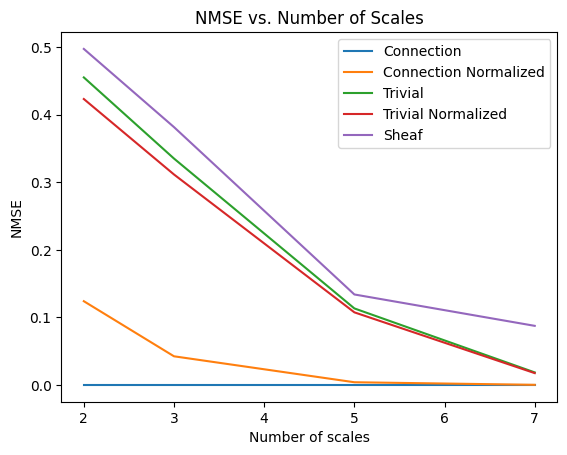

In [9]:
# Plot nmse curves
plt.figure()
for laplacian in laplacians:
    plt.plot(num_scales, [y[1] for y in sorted(cube_nmse_avg[laplacian].items(), key=lambda x: x[0])],label=laplacian)
    plt.xlabel("Number of scales")
    plt.ylabel("NMSE")
plt.title(f"NMSE vs. Number of Scales")
plt.legend()
plt.show()

### Signal Compression: Experiment 2

Use the same set of signals for each laplacian and see how well they perform.


In [ ]:
# Define a set of signals
num_signals = 10
sigma = 3
SEED = 42
signals = np.random.normal(scale=sigma, size=(2*N,num_signals)) # signal dimension = manifold_dim * num_points

# Initialize result dictionaries
sparsity_results = defaultdict(dict)
nmse_results = defaultdict(dict)
num_scales = [2, 3, 5, 7] # number of scales to use
laplacians = ['Connection', 'Connection Normalized', 'Trivial', 'Trivial Normalized', 'Sheaf']

# Hyperparameters
eps=0.1
eps_pca=0.05
k=30
gamma=0.97

for laplacian in laplacians:

    # Create TSP (topological signal processing) object
    cube = TSP(cube_point_cloud, eps=eps, eps_pca=eps_pca, k=k, laplacian_code=laplacian, gamma=gamma)

    for num_scal in num_scales[::-1]:
        # Create dictionary
        dictionary = cube.create_dictionary(scales=[2**(j-num_scal//2) for j in range(num_scal)])

        # Sparsify signals
        sparse_signals = cube.sparsify_signals(signals, dictionary)

        # Compute sparsity
        sparsity =  cube.compute_sparsity(sparse_signals)
        
        # Compute NMSE
        nmse = cube.compute_NMSE(signals, sparse_signals, dictionary)

        # Add sparsity and NMSE to the dictionaries
        sparsity_results[laplacian][num_scal] = sparsity
        nmse_results[laplacian][num_scal] = nmse

## Fibonacci Sphere

In [62]:
N = 300 # number of points
sphere_points = fibonacci_sphere(N) # Generate the Fibonacci sphere
# Create a topological signal processing object
sphere = TSP(sphere_points, eps=0.1, eps_pca=0.05, k=30, gamma=0.95)

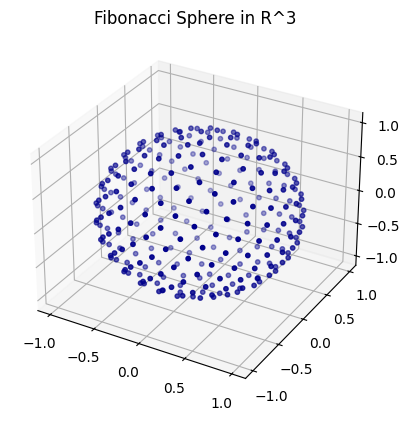

In [16]:
sphere.plot_points('Fibonacci Sphere in R^3')

In [63]:
# Print manifold dimension
print(f"Estimated dimension of the manifold: {sphere.estimate_dim()}")

Estimated dimension of the manifold: 2


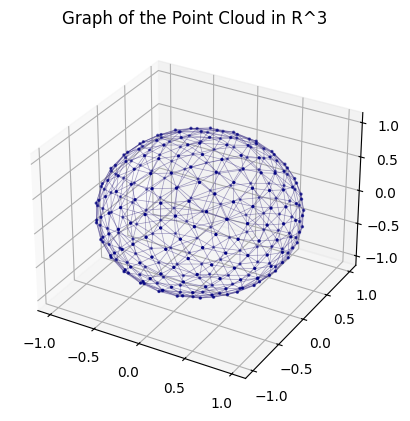

In [18]:
sphere.plot_graph()

In [69]:
from collections import defaultdict

# Initialize result dictionaries
sparsity_results = defaultdict(dict)
nmse_results = defaultdict(dict)
num_scales = [2, 3, 5, 7] # number of scales to use
laplacians = ['Connection', 'Connection Normalized', 'Trivial', 'Trivial Normalized', 'Sheaf']

# Hyperparameters
eps=0.1
eps_pca=0.05
k=30
gamma=0.97

for laplacian in laplacians:

    # Create TSP (topological signal processing) object
    sphere = TSP(sphere_points, eps=eps, eps_pca=eps_pca, k=k, laplacian_code=laplacian, gamma=gamma)

    # Generate signals for the corresponding laplacian
    # signals, cov, signals_GT = sphere.generate_kraichnan_signals(num_signals=2)

    for num_scal in num_scales:
        # Create dictionary
        dictionary = sphere.create_dictionary(scales=[2**(j-num_scal//2) for j in range(num_scal)])

        # Generate signals for the corresponding laplacian and dictionary
        signals = sphere.generate_random_lc_signals(dictionary, num_signals=10)

        # Sparsify signals
        sparse_signals = sphere.sparsify_signals(signals, dictionary)

        # Compute sparsity
        sparsity = sphere.compute_sparsity(sparse_signals)
        
        # Compute NMSE
        nmse = sphere.compute_NMSE(signals, sparse_signals, dictionary)

        # Add sparsity and NMSE to the dictionaries
        sparsity_results[laplacian][num_scal] = sparsity
        nmse_results[laplacian][num_scal] = nmse

In [65]:
# Save the results in pickle files
with open('sphere_sparsity.pkl', 'wb') as f:
    pickle.dump(sparsity_results, f)
with open('sphere_nmse.pkl', 'wb') as f:
    pickle.dump(nmse_results, f)

In [70]:
sparsity_results = pickle.load(open('sphere_sparsity.pkl', 'rb'))
nmse_results = pickle.load(open('sphere_nmse.pkl', 'rb'))

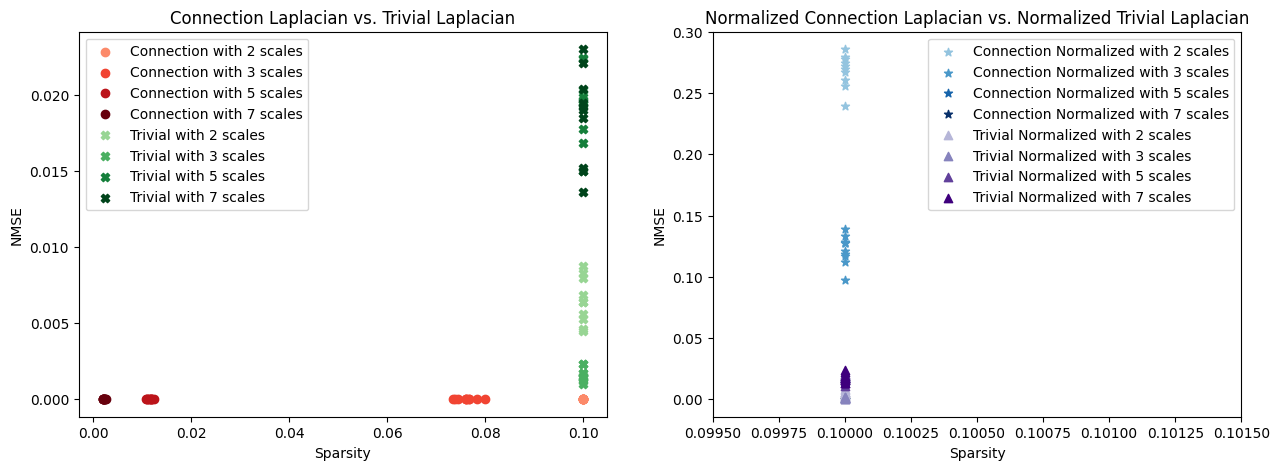

In [71]:
# Scatterplot of sparsity vs. nmse
fig, ax = plt.subplots(1,2, figsize=(15,5))
colors = {
    'Connection': plt.cm.Reds(np.linspace(0.4, 1, len(num_scales))),
    'Connection Normalized': plt.cm.Blues(np.linspace(0.4, 1, len(num_scales))),
    'Trivial': plt.cm.Greens(np.linspace(0.4, 1, len(num_scales))),
    'Trivial Normalized': plt.cm.Purples(np.linspace(0.4, 1, len(num_scales))),
    'Sheaf': plt.cm.Greys(np.linspace(0.4, 1, len(num_scales)))
}
markers = {'Connection': 'o', 'Connection Normalized': '*', 'Trivial': 'X', 'Trivial Normalized': '^', 'Sheaf': 'X',}
for laplacian in ['Connection','Trivial']:
    for l, num_scal in enumerate(num_scales):
        ax[0].scatter(
            sparsity_results[laplacian][num_scal], nmse_results[laplacian][num_scal],
            color=colors[laplacian][l],
            marker=markers[laplacian],
            label=f"{laplacian} with {num_scal} scales"
        )
        ax[0].set_xlabel("Sparsity")
        ax[0].set_ylabel("NMSE")
        ax[0].set_title("Connection Laplacian vs. Trivial Laplacian")
        ax[0].legend()

for laplacian in ['Connection Normalized', 'Trivial Normalized']:
    for l, num_scal in enumerate(num_scales):
        ax[1].scatter(
            sparsity_results[laplacian][num_scal], nmse_results[laplacian][num_scal],
            color=colors[laplacian][l],
            marker=markers[laplacian],
            label=f"{laplacian} with {num_scal} scales"
        )
        ax[1].set_xlabel("Sparsity")
        ax[1].set_ylabel("NMSE")
        ax[1].set_title("Normalized Connection Laplacian vs. Normalized Trivial Laplacian")
        ax[1].set_xlim(0.0995,0.1015)
        ax[1].legend()
plt.show()

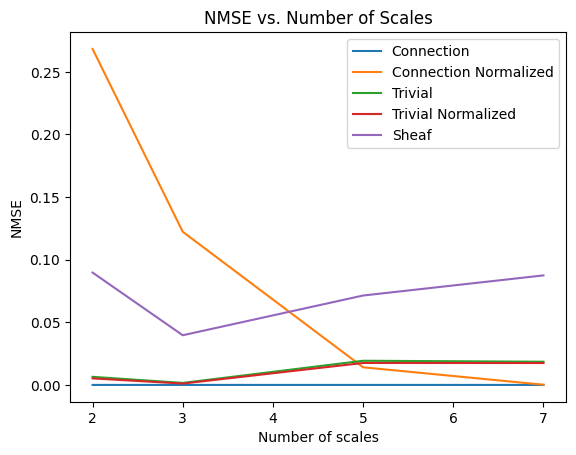

In [72]:
# Plot nmse curves
plt.figure()
for laplacian in laplacians:
    plt.plot(num_scales, [y[1] for y in sorted(cube_nmse_avg[laplacian].items(), key=lambda x: x[0])],label=laplacian)
    plt.xlabel("Number of scales")
    plt.ylabel("NMSE")
plt.title(f"NMSE vs. Number of Scales")
plt.legend()
plt.show()

# Weather Dataset

### Load the Dataset

A csv file is loaded, containing Swiss weather station coordinates and heights. The stations will be the nodes in the graph built by the VDM class.

In [2]:
stations = pd.read_csv('stations_ds.csv')
display(stations)

,nat_abbr,latitude,longitude,station_height
0,ABE,47.057969,7.285350,444.00
1,ABO,46.491703,7.560703,1321.38
2,AEG,47.133636,8.608206,724.43
3,AFI,47.604669,8.670289,360.00
4,AGATT,47.265233,8.050519,475.00
...,...,...,...,...
297,WYN,47.255025,7.787475,421.99
298,ZER,46.029272,7.752433,1638.35
299,ZEV,46.578797,9.118797,1738.00
300,ZWE,46.550511,7.384917,936.00


In [3]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nat_abbr        302 non-null    object 
 1   latitude        302 non-null    float64
 2   longitude       302 non-null    float64
 3   station_height  302 non-null    float64
dtypes: float64(3), object(1)
memory usage: 9.6+ KB


In [4]:
# Turn columns 1,2,3 (latitude, longitude, station_height) to a numpy array
station_geodetic = stations.iloc[:,1:4].to_numpy()
# Turn the coordinates from geodetic to R^3 points
x, y, z = geodetic_to_ecef(
    station_geodetic[:, 0],
    station_geodetic[:, 1],
    station_geodetic[:, 2]
)
station_points = np.column_stack((x, y, z))  # shape (N, 3)
station_points[:10]

array([[0.67575819, 0.08639101, 0.73204334],
       [0.68247416, 0.09058512, 0.72527468],
       [0.6726272 , 0.10182383, 0.7329424 ],
       [0.66653709, 0.10164081, 0.73851029],
       [0.67191781, 0.09503612, 0.73450296],
       [0.6698307 , 0.09771763, 0.73605577],
       [0.67498515, 0.09174883, 0.73210464],
       [0.68550921, 0.08325283, 0.72328838],
       [0.68029226, 0.10285349, 0.72568836],
       [0.66769497, 0.11241116, 0.73589888]])

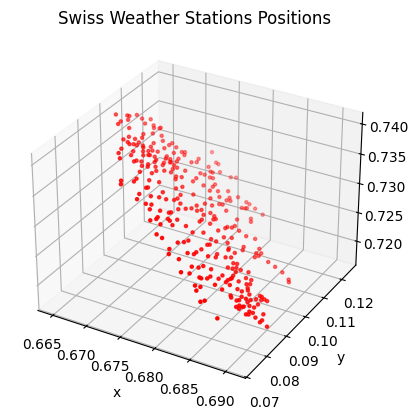

In [5]:
# Plot the cube
fig = plt.figure()  
ax = fig.add_subplot(projection='3d')
ax.scatter(station_points[:,0], station_points[:,1], station_points[:,2], marker='o', s=5, c='red')
plt.title('Swiss Weather Stations Positions')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [6]:
# Find some distance statistics to choose good hyperparameters for the VDM class
def compute_distances(x):
    distances = []
    for i in range(x.shape[0]):
        for j in range(i+1, x.shape[0]):
            dist = np.linalg.norm(x[i] - x[j])
            distances.append(dist)
    return distances

distances = compute_distances(station_points)
print(f"Median distance between two stations: {np.median(distances)}")
print(f"Min and max distances: {np.min(distances)}, {np.max(distances)}")
print("First ten distances:")
print(sorted(distances, reverse=True)[:10])

Median distance between two stations: 0.01761227600907149
Min and max distances: 0.00037039650947565583, 0.05318045111323205
First ten distances:
[np.float64(0.05318045111323205), np.float64(0.05287267455556982), np.float64(0.052071312343405105), np.float64(0.05204996461640956), np.float64(0.05143259099883185), np.float64(0.050794923114699214), np.float64(0.05078056824714675), np.float64(0.05060660727475896), np.float64(0.050562648945038736), np.float64(0.05055124190410377)]


### Build the Graph

In [7]:
x = station_points  # point cloud
eps = 0.0003 # epsilon for the graph
eps_pca = 0.0002 # epsilon for the local PCA
k = 15 # number of neighbors in knn
gamma = 0.997 # information variability threshold in dimension estimation with singular values
vdm = VDM(x, eps, eps_pca, k, gamma)
G = vdm.make_graph()
print(f"Estimated dimension of the manifold: {vdm.estimate_dim()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Graph density: {G.number_of_edges()/(G.number_of_nodes()*(G.number_of_nodes()-1))}")

Estimated dimension of the manifold: 2
Number of edges: 22196
Graph density: 0.244175045653561


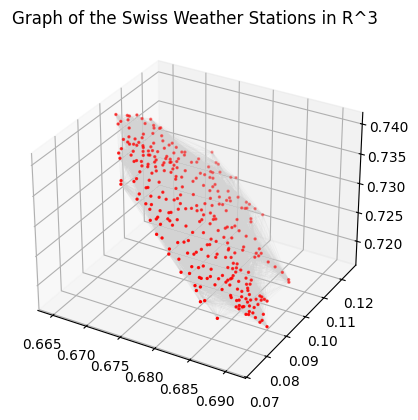

In [64]:
# Plot the graph
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x[:,0], x[:,1], x[:,2], marker='o', s=2, c='red')
# Plot the edges
for edge in G.edges():
    x1, y1, z1 = x[edge[0]]
    x2, y2, z2 = x[edge[1]]
    ax.plot([x1, x2], [y1, y2], [z1, z2], c='lightgrey', linewidth=0.1, alpha=0.5)
plt.title('Graph of the Swiss Weather Stations in R^3')
plt.show()

### Build the Laplacians

##### Connection Laplacian

In [8]:
# Connection Laplacian of the graph, computed as D^-1 @ S - I
L_con = vdm.connection_laplacian() # approximation of the connection laplacian

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(L_con)
idx = np.argsort(eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:,idx]
# Suppress imaginary part if below 1e-15
for i in range(len(eigvals)):
    if np.abs(eigvals[i].imag) < 1e-15:
        eigvals[i] = eigvals[i].real
# If all values are real now, change data type from complex to float
if np.all(np.isreal(eigvals)):
    eigvals = eigvals.astype(np.float64)
print("Complex parts were suppressed because they were all below a 1e-15 tolerance. Data type changed to float64.")
print(f"Min eigenvalue: {eigvals[0]}, Max eigenvalue: {eigvals[-1]}")

Complex parts were suppressed because they were all below a 1e-15 tolerance. Data type changed to float64.
Min eigenvalue: -1.4941219944218032, Max eigenvalue: -0.25608233336434905


##### Trivial Bundle

In [ ]:
# Graph Laplacian
W = vdm.get_weight_matrix() # Weight matrix
d = vdm.get_degree_vector() # degree vector
d_sqrt = np.sqrt(d)
L_trivial = np.diag(d) - W # Graph Laplacian
L_trivial_norm = np.diag(1./d_sqrt) @ L_trivial @ np.diag(d_sqrt) # Normalized Laplacian

### Load Signals

In [108]:
# Load the signals (wind data)
wind_data_uv = np.load('wind_data_uv.npy')
wind_data_uv

array([[-0.9986295 , -0.33456534, -0.93358046, ...,  0.39999998,
         0.9801073 ,  0.52484727],
       [-0.05233597,  0.37157238,  0.35836792, ...,  0.69282037,
        -0.4993893 ,  0.60376763],
       [-0.70139384, -0.68404025, -0.70331603, ...,  1.4571847 ,
         1.0790098 , -0.03838944],
       ...,
       [-2.9870312 , -3.11127   , -3.5460484 , ..., -0.5846221 ,
        -0.48480958, -0.9563047 ],
       [ 0.76604456,  0.7269508 ,  0.7551845 , ...,  0.9439806 ,
         0.860083  ,  1.2362019 ],
       [ 0.6427875 ,  1.0777488 ,  0.9325752 , ...,  1.165719  ,
         2.2405932 ,  3.0597064 ]], shape=(302, 5616), dtype=float32)

In [119]:
u = wind_data_uv[::2,:] # zonal (east–west) wind component
v = wind_data_uv[1::2,:] # meridional (north–south) wind component
# Take the first signal
uv_signal = np.column_stack((u[:,0],v[:,0]))
uv_signal.shape

(151, 2)

In [120]:
uv_signal.shape

(151, 2)

In [123]:
O = vdm.make_orthonormal_bases()
len(O)

302

In [ ]:
# Project the signal point-wise on the tangent space of the graph
O = vdm.make_orthonormal_bases()
# ...